In [26]:
import pandas as pd
import numpy as np

In [27]:
df= pd.read_csv('tested.csv')

In [28]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

In [9]:
print("Duplicate:",df.duplicated().sum())

Duplicate: 0


In [11]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Fare          1
Cabin       327
Embarked      0
dtype: int64

In [17]:
df.drop(columns=["Fare"], inplace=True)

In [18]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
SibSp       0
Parch       0
Embarked    0
dtype: int64

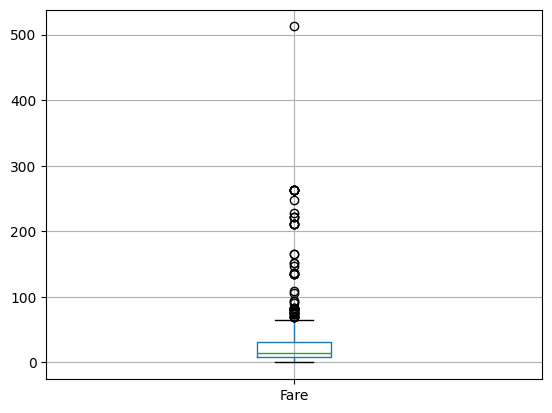

In [29]:
import matplotlib.pyplot as plt
df.boxplot(column="Fare")
plt.show()

In [31]:
Q1=df["Fare"].quantile(0.25)
Q3=df["Fare"].quantile(0.75)
IQR=Q3-Q1

df=df[~((df["Fare"]<(Q1-1.5*IQR))|
        (df["Fare"]>(Q3+1.5*IQR)))]
print("shape After remove outlier",df.shape)

shape After remove outlier (363, 12)


In [35]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder

le = LabelEncoder()
df["Survived"] =le.fit_transform(df["Survived"])
ohe_sex= OneHotEncoder(sparse_output=False,drop="first")
encoded_sex=ohe_sex.fit_transform(df[["Sex"]])
encoded_sex_df = pd.DataFrame(encoded_sex,
                              columns=ohe_sex.get_feature_names_out(["Sex"]),
                              index=df.index)
df=pd.concat([df,encoded_sex_df],axis=1)
df.drop(columns=["Sex"],inplace=True)

oe=OrdinalEncoder(categories=[[1,2,3]])
df[["Pclass"]] =oe.fit_transform(df[["Pclass"]])

In [36]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [37]:
minmax =  MinMaxScaler()
df[["Age"]]=minmax.fit_transform(df[["Age"]])

In [38]:
robust  = RobustScaler()
df[["Fare"]]=robust.fit_transform(df[["Fare"]])

In [39]:
minmax2 = MinMaxScaler()
df[["SibSp"]]=minmax.fit_transform(df[["SibSp"]])

In [40]:
minmax2 = MinMaxScaler()
df[["Parch"]]=minmax.fit_transform(df[["Parch"]])